<a href="https://colab.research.google.com/github/heisokoye/Admin-dashboard/blob/main/TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

df = pd.read_csv("spotify.csv")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.to_csv("spotify.csv", index=False)

In [ ]:
df['artist_name']=df['artist_name'].str.lower()
df['track_name']=df['track_name'].str.lower()
df['album_release_date']=pd.to_datetime(df['album_release_date'])
df.to_csv("spotify.csv", index=False)



In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Remove outliers by keeping only the rows within the bounds
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    print(f"Original rows in '{column}': {len(df)}")
    print(f"Rows after outlier removal for '{column}': {len(df_cleaned)}")
    return df_cleaned

# Apply the outlier removal function to each specified column


# Save the updated DataFrame to spotify.csv
df.to_csv("spotify.csv", index=False)

print("Outlier removal complete and updated DataFrame saved to spotify.csv.")

Outlier removal complete and updated DataFrame saved to spotify.csv.


In [ ]:
df['album_release_date'] = pd.to_datetime(df['album_release_date'])

trend = (
    df
    .groupby(df['album_release_date'].dt.to_period('M'))['track_popularity']
    .mean()
    .to_timestamp()
)


print(trend)

album_release_date
1952-09-01    45.000000
1958-01-01    55.000000
1959-02-01     8.000000
1959-06-01    64.333333
1959-07-01    74.000000
                ...    
2025-06-01    61.583333
2025-07-01    65.027778
2025-08-01    60.469388
2025-09-01    55.531915
2025-10-01    55.730769
Name: track_popularity, Length: 478, dtype: float64


In [ ]:
ts_df = trend.reset_index()
ts_df.columns = ['ds', 'y']

print(ts_df)

            ds          y
0   1952-09-01  45.000000
1   1958-01-01  55.000000
2   1959-02-01   8.000000
3   1959-06-01  64.333333
4   1959-07-01  74.000000
..         ...        ...
473 2025-06-01  61.583333
474 2025-07-01  65.027778
475 2025-08-01  60.469388
476 2025-09-01  55.531915
477 2025-10-01  55.730769

[478 rows x 2 columns]


In [ ]:
ts_df['y'] = ts_df['y'].rolling(window=3, min_periods=1).mean()


In [ ]:
# Split the last 12 months for testing
train_size = len(ts_df) - 12
train_df = ts_df.iloc[:train_size]
test_df = ts_df.iloc[train_size:]

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

Training samples: 466
Testing samples: 12


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


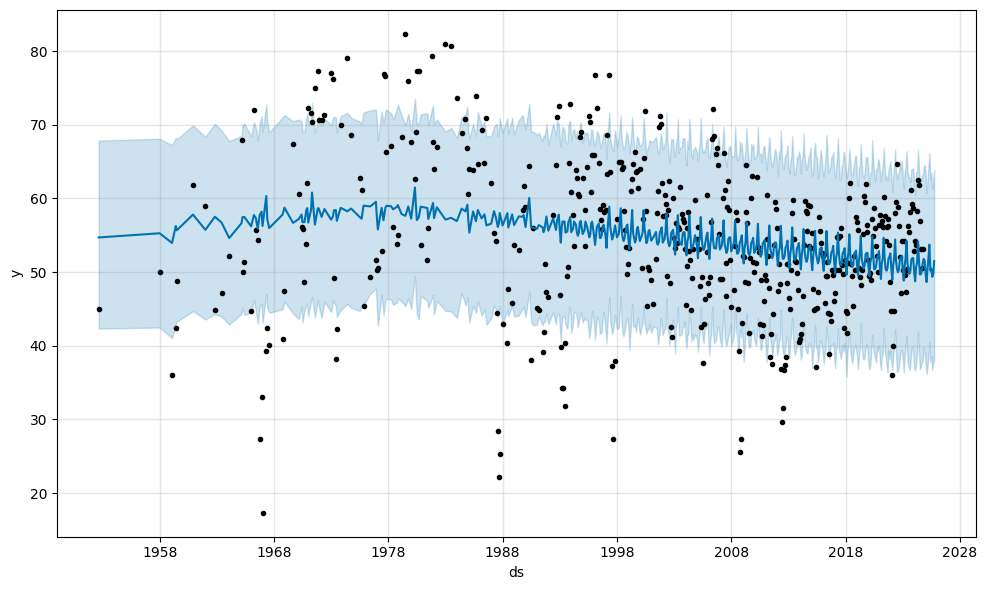

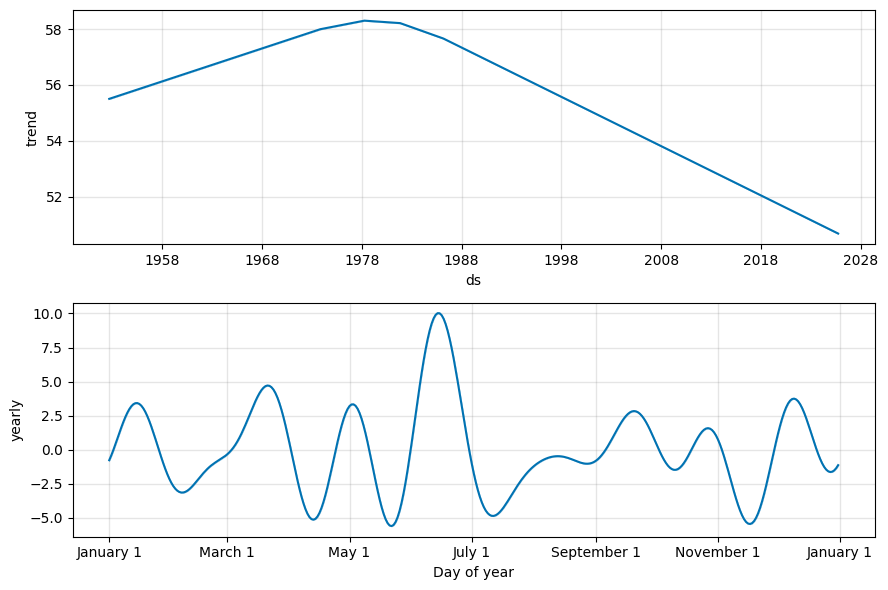

In [ ]:
# Initialize and fit the model
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(train_df)

# Create a dataframe to hold predictions (covering the test period)
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

# Visualize the forecast components




model.plot(forecast)
plt.show()

model.plot_components(forecast)
plt.show()

Mean Absolute Error (MAE): 8.16
Root Mean Squared Error (RMSE): 9.35


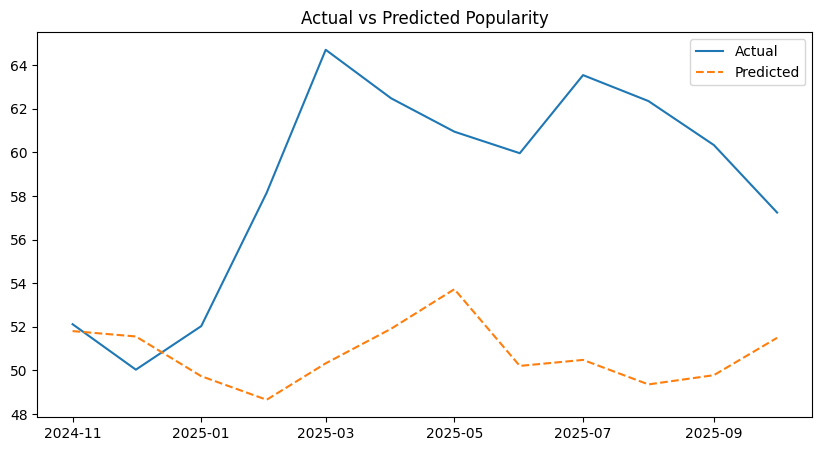

In [ ]:
# Extract predictions for the test period
predictions = forecast.iloc[-12:]['yhat']
actuals = test_df['y']

# Calculate Metrics
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(test_df['ds'], actuals, label='Actual')
plt.plot(test_df['ds'], predictions, label='Predicted', linestyle='--')
plt.legend()
plt.title('Actual vs Predicted Popularity')
plt.show()